In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv


In [2]:
train =pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, BaggingClassifier, AdaBoostClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [4]:
print(f"Training set  : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Test set      : {test.shape[0]:,} rows × {test.shape[1]} columns")
print(f"Sample sub    : {sample_sub.shape}")
train.head()

Training set  : 7,000 rows × 6 columns
Test set      : 1,700 rows × 5 columns
Sample sub    : (1700, 2)


,id,phrase,feature_1,feature_2,feature_3,sentiment
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0
1,1,You have to see it .,6.0,1.0,NaN,2
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1
3,3,Watching Harris ham it up while physically and...,37.0,NaN,3.0,1
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2


In [5]:
print("=== Training Data Types ===")
print(train.dtypes)
print()
print("=== Test Data Types ===")
print(test.dtypes)

=== Training Data Types ===
id             int64
phrase        object
feature_1    float64
feature_2    float64
feature_3    float64
sentiment      int64
dtype: object

=== Test Data Types ===
id             int64
phrase        object
feature_1    float64
feature_2    float64
feature_3    float64
dtype: object


In [6]:
num_cols = ['feature_1', 'feature_2', 'feature_3']
desc = train[num_cols + ['sentiment']].describe().T
desc['median'] = train[num_cols + ['sentiment']].median()
desc = desc[['count','mean','median','std','min','25%','50%','75%','max']]
print(desc.round(3).to_string())

            count    mean  median    std  min   25%   50%   75%   max
feature_1  6088.0  19.026    18.0  9.304  1.0  12.0  18.0  25.0  52.0
feature_2  5896.0   1.997     1.0  1.635  0.0   1.0   1.0   3.0  19.0
feature_3  5938.0   3.334     3.0  2.321  0.0   2.0   3.0   4.0  19.0
sentiment  7000.0   1.041     1.0  0.898  0.0   0.0   1.0   2.0   2.0


In [7]:
print("=== Missing Values — Train ===")
missing_train = train.isnull().sum()
pct_train = (missing_train / len(train) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing_train, 'Missing %': pct_train})
print(mv_df[mv_df['Missing Count'] > 0])

print()
print("=== Missing Values — Test ===")
missing_test = test.isnull().sum()
pct_test = (missing_test / len(test) * 100).round(2)
mv_df2 = pd.DataFrame({'Missing Count': missing_test, 'Missing %': pct_test})
print(mv_df2[mv_df2['Missing Count'] > 0])

=== Missing Values — Train ===
           Missing Count  Missing %
feature_1            912      13.03
feature_2           1104      15.77
feature_3           1062      15.17

=== Missing Values — Test ===
           Missing Count  Missing %
feature_1            222      13.06
feature_2            318      18.71
feature_3             90       5.29


In [8]:
# Strategy: Median imputation for numerical features
# Median is robust to outliers and preserves the distribution better than mean for skewed data
imputer = SimpleImputer(strategy='median')
train[num_cols] = imputer.fit_transform(train[num_cols])
test[num_cols]  = imputer.transform(test[num_cols])   # use train's medians on test

print("After imputation — missing values in train:")
print(train[num_cols].isnull().sum())
print()
print("After imputation — missing values in test:")
print(test[num_cols].isnull().sum())
print()
print("✅ Median imputation applied. Fit on train, transformed on both train and test.")

After imputation — missing values in train:
feature_1    0
feature_2    0
feature_3    0
dtype: int64

After imputation — missing values in test:
feature_1    0
feature_2    0
feature_3    0
dtype: int64

✅ Median imputation applied. Fit on train, transformed on both train and test.


In [9]:
dup_count = train.duplicated().sum()
dup_phrase = train.duplicated(subset=['phrase']).sum()
print(f"Fully duplicate rows      : {dup_count}")
print(f"Duplicate phrases         : {dup_phrase}")

if dup_count > 0:
    print(f"Dropping {dup_count} duplicate rows...")
    train = train.drop_duplicates().reset_index(drop=True)
    print(f"Shape after dropping: {train.shape}")
else:
    print("✅ No duplicate rows found — no action needed.")

Fully duplicate rows      : 0
Duplicate phrases         : 177
✅ No duplicate rows found — no action needed.


In [10]:
train.duplicated(subset=['phrase']).sum()

np.int64(177)

In [11]:
train.groupby('phrase')['sentiment'].nunique().value_counts()

sentiment
1    6823
Name: count, dtype: int64

In [12]:
train.shape

(7000, 6)

In [13]:
train = train.drop_duplicates(subset=['phrase'])
train.shape

(6823, 6)

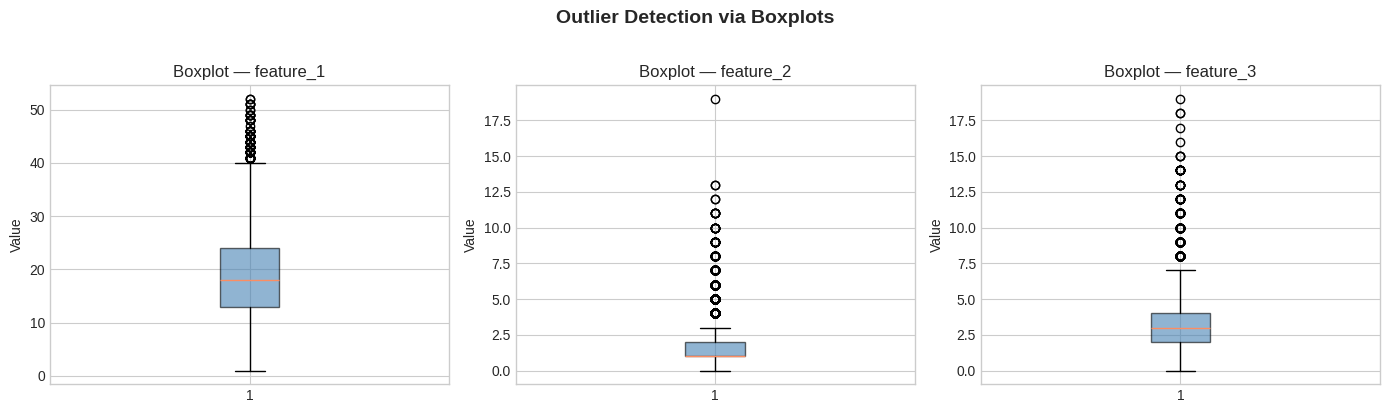

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    axes[i].boxplot(train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'Boxplot — {col}', fontsize=12)
    axes[i].set_ylabel('Value')
plt.suptitle('Outlier Detection via Boxplots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# IQR-based outlier detection
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, "
          f"bounds=[{lower:.1f}, {upper:.1f}], outliers={n_out}")

feature_1: Q1=13.0, Q3=24.0, IQR=11.0, bounds=[-3.5, 40.5], outliers=117
feature_2: Q1=1.0, Q3=2.0, IQR=1.0, bounds=[-0.5, 3.5], outliers=826
feature_3: Q1=2.0, Q3=4.0, IQR=2.0, bounds=[-1.0, 7.0], outliers=323


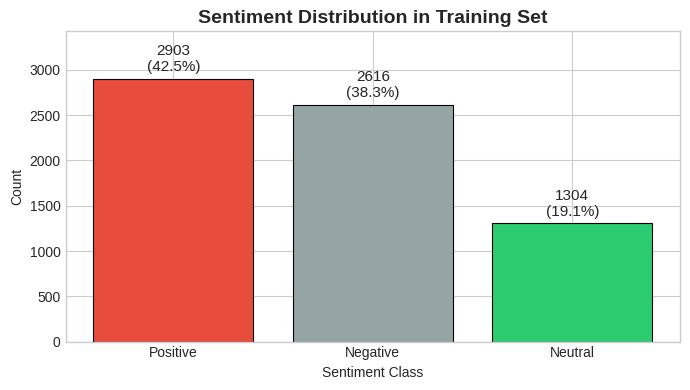

sentiment
Positive    2903
Negative    2616
Neutral     1304
Name: count, dtype: int64


In [16]:
label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
counts = train['sentiment'].map(label_map).value_counts()
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val}\n({val/len(train)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('Sentiment Distribution in Training Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) * 1.18)
plt.tight_layout()
plt.show()
print(counts)

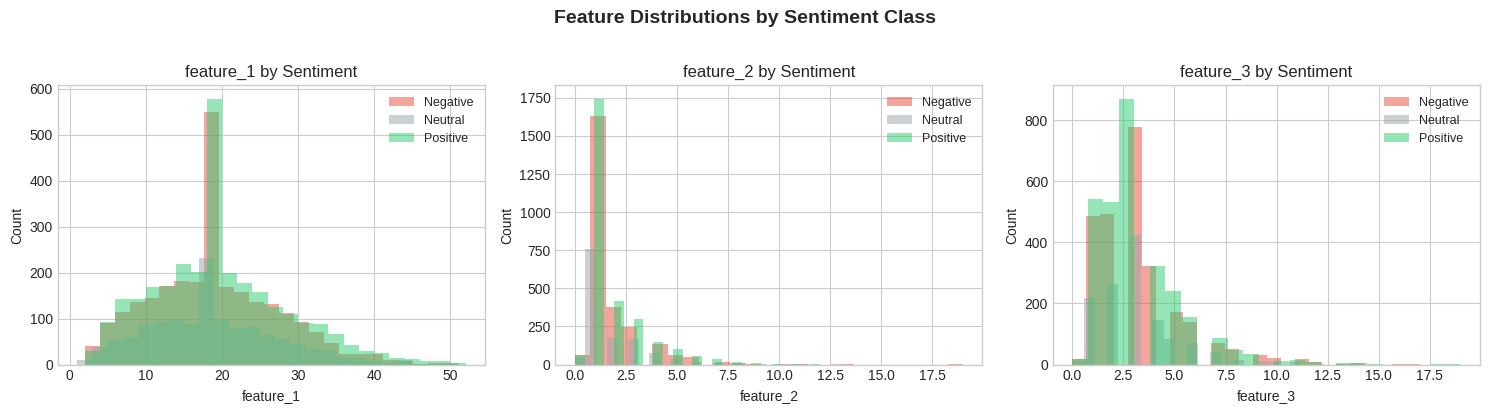

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sentiment_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
palette = {0: '#e74c3c', 1: '#95a5a6', 2: '#2ecc71'}

for i, col in enumerate(num_cols):
    for s, lbl in sentiment_labels.items():
        subset = train[train['sentiment'] == s][col]
        axes[i].hist(subset, bins=25, alpha=0.5, label=lbl, color=palette[s], edgecolor='none')
    axes[i].set_title(f'{col} by Sentiment', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions by Sentiment Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

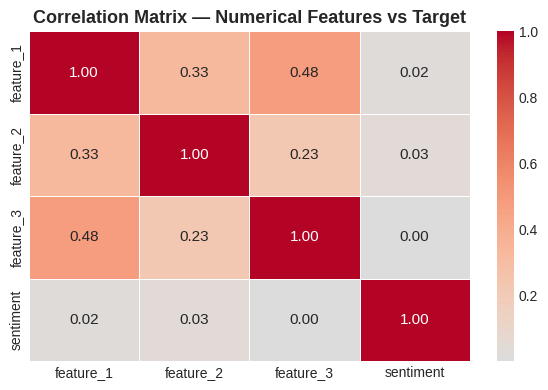

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
corr = train[num_cols + ['sentiment']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Correlation Matrix — Numerical Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00


In [20]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

In [21]:
train['vader_score'] = train['phrase'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

test['vader_score'] = test['phrase'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

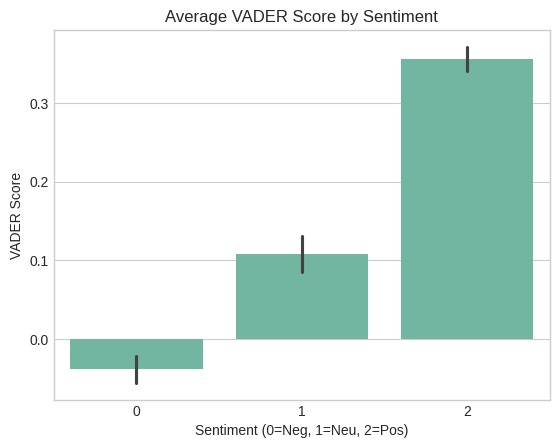

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='sentiment', y='vader_score', data=train)
plt.title("Average VADER Score by Sentiment")
plt.xlabel("Sentiment (0=Neg, 1=Neu, 2=Pos)")
plt.ylabel("VADER Score")
plt.show()

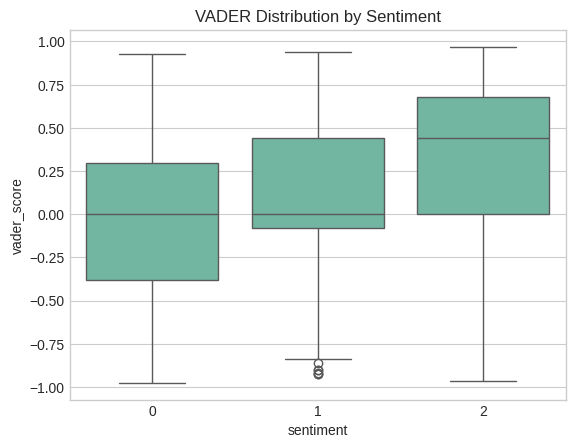

In [23]:
sns.boxplot(x='sentiment', y='vader_score', data=train)
plt.title("VADER Distribution by Sentiment")
plt.show()

In [24]:
train.head()

,id,phrase,feature_1,feature_2,feature_3,sentiment,vader_score
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0,0.2732
1,1,You have to see it .,6.0,1.0,3.0,2,0.0000
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1,0.0000
3,3,Watching Harris ham it up while physically and...,37.0,1.0,3.0,1,-0.2263
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2,0.6486


In [25]:
!pip install textblob

In [26]:
from textblob import TextBlob

train['blob_score'] = train['phrase'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

test['blob_score'] = test['phrase'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [27]:
train.head()

,id,phrase,feature_1,feature_2,feature_3,sentiment,vader_score,blob_score
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.0,7.0,0,0.2732,0.000000
1,1,You have to see it .,6.0,1.0,3.0,2,0.0000,0.000000
2,2,... either you 're willing to go with this cla...,16.0,0.0,6.0,1,0.0000,-0.250000
3,3,Watching Harris ham it up while physically and...,37.0,1.0,3.0,1,-0.2263,0.075255
4,4,Pete 's screenplay manages to find that real n...,20.0,1.0,4.0,2,0.6486,0.150000


In [28]:
from sklearn.model_selection import train_test_split
X = train.drop(columns = ['sentiment','id'])
y = train['sentiment']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
X_train.head()

,phrase,feature_1,feature_2,feature_3,vader_score,blob_score
321,I loved this film .,5.0,1.0,1.0,0.5994,0.7000
1898,The only thing I laughed at were the people wh...,15.0,2.0,1.0,0.4588,0.3500
3759,If you think it 's a riot to see Rob Schneider...,18.0,6.0,5.0,-0.6124,0.2500
6406,If you can tolerate the redneck-versus-blueblo...,28.0,6.0,6.0,0.4588,0.3500
1468,What 's left is a rich stew of longing .,10.0,1.0,3.0,0.5423,0.1875


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),   # 🔥 THIS matters
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train['phrase'])
X_val_tfidf = tfidf.transform(X_val['phrase'])

In [31]:
X_train_extra = X_train[['vader_score','blob_score']].values
X_val_extra = X_val[['vader_score','blob_score']].values

from scipy.sparse import hstack

X_train_final = hstack([X_train_tfidf, X_train_extra])
X_val_final = hstack([X_val_tfidf, X_val_extra])

In [32]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

model = LinearSVC(C=1)
model.fit(X_train_final, y_train)

pred = model.predict(X_val_final)
print("Validation Accuracy:", accuracy_score(y_val, pred))

Validation Accuracy: 0.663003663003663


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, C=2),
    "SVM (LinearSVC)": LinearSVC(C=2, max_iter=3000),
    
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # ⚠️ Tree models need dense data
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting", "AdaBoost"]:
        model.fit(X_train_final.toarray(), y_train)
        pred = model.predict(X_val_final.toarray())
    else:
        model.fit(X_train_final, y_train)
        pred = model.predict(X_val_final)
    
    acc = accuracy_score(y_val, pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print("-"*40)

print("\nFinal Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

Training Logistic Regression...
Logistic Regression Accuracy: 0.6762
----------------------------------------
Training SVM (LinearSVC)...
SVM (LinearSVC) Accuracy: 0.6498
----------------------------------------
Training Decision Tree...
Decision Tree Accuracy: 0.5018
----------------------------------------
Training Random Forest...
Random Forest Accuracy: 0.6381
----------------------------------------

Final Results:
Logistic Regression: 0.6762
SVM (LinearSVC): 0.6498
Decision Tree: 0.5018
Random Forest: 0.6381


In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    'C': [0.1, 0.5, 1, 2, 5]
}

grid_svm = GridSearchCV(
    LinearSVC(max_iter=3000),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train_final, y_train)

print("Best SVM:", grid_svm.best_params_)
print("Score:", grid_svm.best_score_)

Best SVM: {'C': 0.5}
Score: 0.6247724970649654


In [35]:
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.1, 0.5, 1, 2, 5]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=3000),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_final, y_train)

print("Best LR:", grid_lr.best_params_)
print("Score:", grid_lr.best_score_)

Best LR: {'C': 2}
Score: 0.6253220483017076


In [36]:
from sklearn.naive_bayes import MultinomialNB

param_grid = {
    'alpha': [0.1, 0.5, 1.0]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train_tfidf, y_train)

print("Best NB:", grid_nb.best_params_)
print("Score:", grid_nb.best_score_)

Best NB: {'alpha': 0.5}
Score: 0.6233040736064376


In [37]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Fit ONLY on training data
X_train_vader_scaled = scaler.fit_transform(X_train[['vader_score']])

# Transform validation
X_val_vader_scaled = scaler.transform(X_val[['vader_score']])
from scipy.sparse import hstack

X_train_nb = hstack([X_train_tfidf, X_train_vader_scaled])
X_val_nb = hstack([X_val_tfidf, X_val_vader_scaled])

In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()
nb_model.fit(X_train_nb, y_train)

pred = nb_model.predict(X_val_nb)
print("NB Accuracy:", accuracy_score(y_val, pred))


NB Accuracy: 0.6366300366300366


In [39]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),   # 🔥 THIS matters
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_text = tfidf.fit_transform(train['phrase'])
X_test_text = tfidf.transform(test['phrase'])

In [40]:
from scipy.sparse import hstack

X_extra = train[['vader_score']].values
X_test_extra = test[['vader_score']].values

X_final = hstack([X_text, X_extra])
X_test_final = hstack([X_test_text, X_test_extra])

y = train['sentiment']

In [41]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(
    max_iter=3000,
    C=3,                 # or whatever best you got
    class_weight='balanced'
)

final_model.fit(X_final, y)

LogisticRegression(C=3, class_weight='balanced', max_iter=3000)

In [42]:
test_pred = final_model.predict(X_test_final)

In [43]:
import pandas as pd

submission = pd.DataFrame({
    'id': test['id'],
    'sentiment': test_pred
})

submission.to_csv('submission.csv', index=False)

In [44]:
submission.head()

,id,sentiment
0,0,1
1,1,2
2,2,2
3,3,2
4,4,1


In [45]:
submission.shape

(1700, 2)

In [46]:
submission.isnull().sum()

id           0
sentiment    0
dtype: int64